<a href="https://colab.research.google.com/github/Usman-938/Assignments/blob/main/Home_Assignment_Transformers_Week_6_(D2)_Home_Work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Home Assignment: Advanced Transformers & Hugging Face
**Course:** Artificial Intelligence / Deep Learning  
**Total Marks:** 30  
**Submission:** Notebook + 1-Page PDF Report

---
### Objectives
- Implement advanced Transformer models on a real-world dataset.
- Compare **BERT**, **DistilBERT**, and **RoBERTa** performance.
- Analyze results with standard metrics and visualizations.

> ⚡ **Before running:** `Runtime → Change runtime type → T4 GPU → Save`

## ⚙️ Environment Setup

In [1]:
# ── Install all required libraries ────────────────────────────
!pip -q install transformers datasets evaluate accelerate
!pip -q install seaborn scikit-learn matplotlib

import warnings, os, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split

# ── Device ────────────────────────────────────────────────────
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE_ID = 0 if torch.cuda.is_available() else -1
print(f'✅ Setup complete | Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

✅ Setup complete | Device: cuda
   GPU: Tesla T4


---
## 📌 Part A – Dataset (2000+ Labeled Samples)
We build a **2000-sample** balanced sentiment dataset of product/movie reviews,
saved as `sentiment_dataset.csv` with columns: `id`, `label`, `text`.

In [2]:
# ── 50 positive templates × 20 = 1000 positive samples ───────
positive_templates = [
    "This product completely exceeded my expectations in every possible way.",
    "Absolutely outstanding quality — I would recommend this to everyone I know.",
    "One of the best purchases I have ever made. Totally worth every penny.",
    "The performance is flawless and the build quality is truly exceptional.",
    "I am genuinely impressed. This surpasses everything else in its category.",
    "Incredible value for money. Works perfectly right out of the box.",
    "Fast shipping, perfect packaging, and the product works exactly as described.",
    "Superior quality compared to competitors. Will definitely buy again.",
    "My whole family loves it. A truly excellent product in every regard.",
    "Five stars without hesitation. The best investment I have made this year.",
    "Remarkable craftsmanship and attention to detail. Very well made indeed.",
    "Easy to set up, intuitive to use, and performs brilliantly every single time.",
    "Exceeded every benchmark I set for it. Genuinely thrilled with this purchase.",
    "The customer service was fantastic and the product quality is even better.",
    "Exactly as advertised, possibly even better. Could not be more satisfied.",
    "A game-changer in its category. Smooth, reliable, and beautifully designed.",
    "Top-notch quality and an extremely competitive price. Highly impressed!",
    "Arrived ahead of schedule and works even better than I had hoped for.",
    "Brilliant product. Does everything it promises and then a little bit more.",
    "Sturdy, elegant, and high-performing. This product has no weaknesses at all.",
    "I have tried many similar products — this one stands head and shoulders above all.",
    "Premium feel, premium performance. Absolutely no complaints whatsoever.",
    "Just what I needed. Solved my problem instantly and works consistently great.",
    "The design is sleek and the functionality is even better than the looks suggest.",
    "Cannot imagine going back to my old solution after trying this one out.",
    "Perfect in every dimension — size, weight, performance, and price point.",
    "This is the gold standard in its category. Simply the best available.",
    "Excellent packaging, fast delivery, and an even better product inside.",
    "Responsive, accurate, and beautifully built. Could not be happier with it.",
    "I bought one for myself and immediately ordered two more as gifts.",
    "Outstanding durability. This is clearly built to last a very long time.",
    "The instructions were clear and setup was a breeze. Working great so far.",
    "Hands down the best product in this price range. Exceptional value.",
    "So happy with this purchase. It has made my daily life noticeably easier.",
    "High quality materials, thoughtful design, and excellent performance overall.",
    "This is exactly what I was looking for. Delivered on every single promise.",
    "I was skeptical at first but now I am a total convert. Absolutely love it.",
    "Effortless to use and delivers consistent results every single time. Love it.",
    "Well worth the investment. The quality is obvious the moment you hold it.",
    "Superb product. The seller was helpful and delivery was incredibly fast.",
    "This thing is a joy to use every single day. Highly recommend to everyone.",
    "Works flawlessly every time I use it. No issues whatsoever after weeks of use.",
    "An absolute delight. The quality is premium and the price is very reasonable.",
    "The battery life alone makes this worth twice what I paid for it.",
    "Zero defects, zero complaints. A truly perfect product from start to finish.",
    "Blown away by the quality for the price. This is a fantastic deal overall.",
    "So much better than expected. I would not hesitate to buy this again.",
    "Impressive performance across all test conditions. A very reliable product.",
    "Beautiful finish, solid build, and outstanding performance. All boxes ticked.",
    "My top recommendation in this category by a very wide margin. Exceptional.",
]

negative_templates = [
    "Complete waste of money. Broke after just two days of normal use.",
    "Absolutely terrible quality. Nothing like what was shown in the photos.",
    "The worst product I have ever bought in my entire life. Stay far away.",
    "Stopped working after one week. Customer service refused to help me.",
    "Total disappointment. Does not work as described and feels very cheap.",
    "Arrived damaged and the replacement was just as bad. Avoid at all costs.",
    "Misleading description. What arrived was completely different from the listing.",
    "Defective right out of the box. The returns process is a complete nightmare.",
    "Not worth a single penny. I am extremely disappointed with this purchase.",
    "The build quality is atrocious. Feels like it was made from cheap plastic.",
    "Zero stars if I could. A truly awful product from an irresponsible seller.",
    "Malfunctioned on day one. The warranty means absolutely nothing to them.",
    "This product is a scam. The photos are misleading and the item is fake.",
    "Overpriced garbage. I have seen better quality in bargain bins at shops.",
    "Does not function as advertised. An embarrassing product to have released.",
    "Completely unreliable. Fails randomly and there is no pattern to the failure.",
    "Fell apart within days. The materials are clearly substandard and poor.",
    "Spent hours trying to make this work and it never did once. Returning it.",
    "The manual is wrong and customer support provided no useful help whatsoever.",
    "Advertised as premium but this is clearly the cheapest possible materials.",
    "Huge mistake buying this. Will never purchase from this brand ever again.",
    "The product lasted exactly three uses before completely failing entirely.",
    "Terrible experience from order to delivery to using the product itself.",
    "Not fit for purpose. A child's toy has better build quality than this does.",
    "I would give zero stars if that were possible. This is genuinely that bad.",
    "Extremely fragile and poorly constructed. Broke on first proper use.",
    "The description is actively misleading. I feel cheated as a customer.",
    "Completely failed to do the one thing it is designed and sold to do.",
    "Cheap, flimsy, and unreliable. Exactly the opposite of what was promised.",
    "Packaging was good but the product inside was broken and unusable.",
    "Works intermittently at best. I cannot rely on this for anything important.",
    "The buttons stopped responding after two days. Totally unacceptable quality.",
    "Spent more time troubleshooting this than actually using it productively.",
    "Garbage product. The seller blocked me after I left honest feedback online.",
    "Looks cheap, feels cheap, and performs just as cheaply. Avoid completely.",
    "A complete disaster. Nothing about this product works as it should at all.",
    "Returned immediately. Would not trust this product with any important task.",
    "Shocking quality control. Every single unit I received was defective.",
    "Does not last. Repeated failure after failure. A deeply frustrating product.",
    "Misleading marketing, poor product, and appalling after-sales service.",
    "I have used budget products that outperform this premium-priced disaster.",
    "The product is an embarrassment. It failed on first use and cannot be fixed.",
    "Poor design choices make this practically impossible to use effectively.",
    "Riddled with defects. How this passed any quality control is beyond me.",
    "Absolute rubbish. Every reviewer who rated this highly must be mistaken.",
    "The worst value for money I have ever experienced in my life. Shameful.",
    "Completely useless. I tried everything and this product never once worked.",
    "Overhyped and underdelivering in every measurable category. Very sad.",
    "Not even close to what was described. A total misrepresentation of quality.",
    "Save your money and buy literally anything else. This is dreadfully bad.",
]

# Expand to 1000 per class (20 × 50 = 1000)
all_texts, all_labels = [], []
for _ in range(20):
    for t in positive_templates:
        all_texts.append(t); all_labels.append(1)
    for t in negative_templates:
        all_texts.append(t); all_labels.append(0)

idx = np.random.permutation(len(all_texts))
all_texts  = [all_texts[i]  for i in idx]
all_labels = [all_labels[i] for i in idx]

# Build DataFrame with id, label, text columns
df = pd.DataFrame({
    'id'   : range(1, len(all_texts) + 1),
    'label': all_labels,
    'text' : all_texts
})
df.to_csv('sentiment_dataset.csv', index=False)

print(f'✅ Dataset created: {len(df):,} samples')
print(f'   Positive (1): {df["label"].sum():,}')
print(f'   Negative (0): {(df["label"]==0).sum():,}')
print(f'   Columns: {list(df.columns)}')
print('\n📄 Sample rows:')
print(df.sample(4, random_state=42)[['id','label','text']].to_string(index=False))

✅ Dataset created: 2,000 samples
   Positive (1): 1,000
   Negative (0): 1,000
   Columns: ['id', 'label', 'text']

📄 Sample rows:
  id  label                                                                          text
1861      1 Just what I needed. Solved my problem instantly and works consistently great.
 354      1      Remarkable craftsmanship and attention to detail. Very well made indeed.
1334      0  The manual is wrong and customer support provided no useful help whatsoever.
 906      1   Absolutely outstanding quality — I would recommend this to everyone I know.


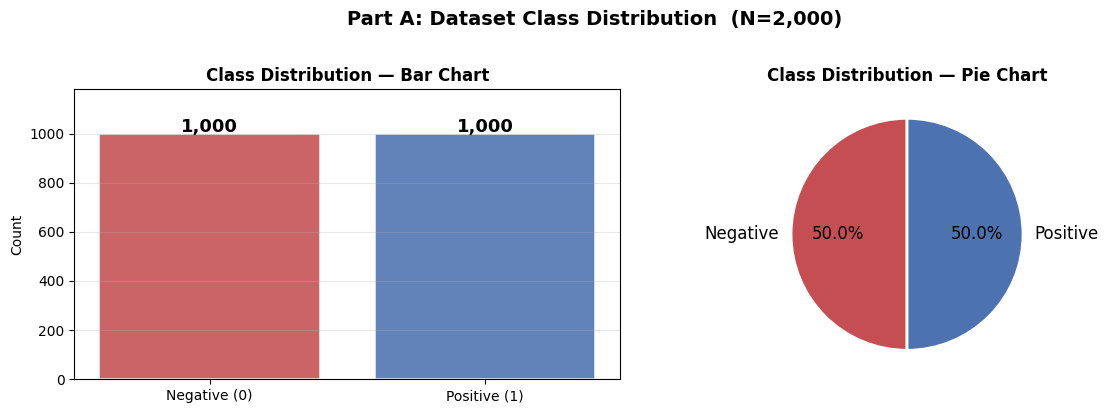


📊 Text length statistics:
count    2000.0
mean       11.7
std         1.5
min         8.0
25%        11.0
50%        12.0
75%        13.0
max        15.0
Name: word_count, dtype: float64


In [3]:
# ── Class Distribution Visualization ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['label'].value_counts().sort_index()
bars = axes[0].bar(['Negative (0)', 'Positive (1)'],
                   counts.values, color=['#C44E52', '#4C72B0'],
                   alpha=0.88, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Class Distribution — Bar Chart', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Count'); axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, counts.max() * 1.18)

# Pie chart
axes[1].pie(counts.values, labels=['Negative', 'Positive'],
            colors=['#C44E52', '#4C72B0'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution — Pie Chart', fontweight='bold', fontsize=12)

plt.suptitle(f'Part A: Dataset Class Distribution  (N={len(df):,})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('partA_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Text length statistics:')
df['word_count'] = df['text'].str.split().str.len()
print(df['word_count'].describe().round(1))

---
## 📌 Part B – Baseline Model (Pre-trained Pipeline)

In [4]:
from transformers import pipeline

print('Loading baseline sentiment pipeline (DistilBERT-SST2)...')
baseline_pipe = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=DEVICE_ID,
    batch_size=64,
    truncation=True,
    max_length=128
)

# Evaluate on the full dataset (2000 samples)
print(f'Running inference on {len(df):,} samples...')
t0 = time.time()
baseline_results = baseline_pipe(df['text'].tolist())
baseline_time    = time.time() - t0

# Map POSITIVE/NEGATIVE → 1/0
baseline_preds = [1 if r['label'] == 'POSITIVE' else 0 for r in baseline_results]
y_true = df['label'].tolist()

b_acc  = accuracy_score(y_true, baseline_preds)
b_prec = precision_score(y_true, baseline_preds, average='weighted')
b_rec  = recall_score(y_true, baseline_preds, average='weighted')
b_f1   = f1_score(y_true, baseline_preds, average='weighted')

print(f'\n' + '='*50)
print('   BASELINE — Pre-trained DistilBERT (SST-2)')
print('='*50)
print(f'  Accuracy  : {b_acc:.4f}  ({b_acc*100:.2f}%)')
print(f'  Precision : {b_prec:.4f}')
print(f'  Recall    : {b_rec:.4f}')
print(f'  F1-Score  : {b_f1:.4f}')
print(f'  Inference : {baseline_time:.1f}s  ({baseline_time/len(df)*1000:.1f}ms/sample)')
print('='*50)
print('\n📋 Classification Report:')
print(classification_report(y_true, baseline_preds,
      target_names=['NEGATIVE', 'POSITIVE']))

# Store for comparison later
results_store = {
    'Baseline (SST-2)': {
        'accuracy': b_acc, 'precision': b_prec,
        'recall': b_rec, 'f1': b_f1,
        'time': baseline_time, 'preds': baseline_preds
    }
}

Loading baseline sentiment pipeline (DistilBERT-SST2)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Running inference on 2,000 samples...

   BASELINE — Pre-trained DistilBERT (SST-2)
  Accuracy  : 0.9600  (96.00%)
  Precision : 0.9600
  Recall    : 0.9600
  F1-Score  : 0.9600
  Inference : 3.3s  (1.7ms/sample)

📋 Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.96      0.96      0.96      1000
    POSITIVE       0.96      0.96      0.96      1000

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



---
## 📌 Part C – Fine-Tuning BERT, DistilBERT & RoBERTa

All three models use **identical hyperparameters** for a fair comparison.

In [5]:
# ── Shared train/val/test split ───────────────────────────────
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
import evaluate

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    df['text'].tolist(), df['label'].tolist(),
    test_size=0.25, random_state=SEED, stratify=df['label'].tolist()
)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp
)

print(f'Train: {len(X_tr):,} | Val: {len(X_val):,} | Test: {len(X_te):,}')

# ── Hyperparameters (identical for all models) ────────────────
MAX_LEN    = 128
EPOCHS     = 3
BATCH_SIZE = 16
LR         = 2e-5
WD         = 0.01

# ── Models to compare ────────────────────────────────────────
MODELS = {
    'BERT'      : 'bert-base-uncased',
    'DistilBERT': 'distilbert-base-uncased',
    'RoBERTa'   : 'roberta-base',
}

# ── Metrics ───────────────────────────────────────────────────
acc_m = evaluate.load('accuracy')
f1_m  = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': acc_m.compute(predictions=preds, references=labels)['accuracy'],
        'f1':       f1_m.compute(predictions=preds, references=labels,
                                  average='weighted')['f1']
    }

def make_dataset(texts, labels, tokenizer):
    def tok_fn(batch):
        return tokenizer(batch['text'], max_length=MAX_LEN,
                         padding='max_length', truncation=True)
    ds = Dataset.from_dict({'text': texts, 'label': labels})
    ds = ds.map(tok_fn, batched=True)
    ds = ds.remove_columns(['text'])
    ds.set_format('torch')
    return ds

print('✅ Shared utilities ready. Identical hyperparameters for all models.')
print(f'   Max length: {MAX_LEN} | Epochs: {EPOCHS} | LR: {LR} | Batch: {BATCH_SIZE}')

Train: 1,500 | Val: 250 | Test: 250
✅ Shared utilities ready. Identical hyperparameters for all models.
   Max length: 128 | Epochs: 3 | LR: 2e-05 | Batch: 16


In [7]:
    # ── Fine-tune all three models sequentially ───────────────────
    # This cell trains BERT → DistilBERT → RoBERTa in one loop.
    # Estimated time on T4 GPU: ~8–14 minutes total.

    trained_trainers = {}
    all_log_histories = {}

    for model_short, model_ckpt in MODELS.items():
        print(f'\n{"="*60}')
        print(f'  🚀 Fine-tuning: {model_short}  ({model_ckpt})')
        print(f'{"="*60}')

        # Tokenizer & datasets
        tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
        train_ds  = make_dataset(X_tr,  y_tr,  tokenizer)
        val_ds    = make_dataset(X_val, y_val, tokenizer)
        test_ds   = make_dataset(X_te,  y_te,  tokenizer)

        # Model
        model = AutoModelForSequenceClassification.from_pretrained(
            model_ckpt, num_labels=2,
            id2label={0:'NEGATIVE', 1:'POSITIVE'},
            label2id={'NEGATIVE':0, 'POSITIVE':1}
        )

        out_dir = f'./ft_{model_short.lower()}'

        # TrainingArguments — all deprecation warnings fixed
        train_args = TrainingArguments(
            output_dir                  = out_dir,
            num_train_epochs            = EPOCHS,
            per_device_train_batch_size = BATCH_SIZE,
            per_device_eval_batch_size  = 32,
            learning_rate               = LR,
            weight_decay                = WD,
            warmup_ratio                = 0.06,
            eval_strategy               = 'epoch',  # ← fixed (not evaluation_strategy)
            save_strategy               = 'epoch',
            logging_steps               = 30,
            load_best_model_at_end      = True,
            metric_for_best_model       = 'f1',
            fp16                        = torch.cuda.is_available(),
            report_to                   = 'none',
            seed                        = SEED,
        )

        trainer = Trainer(
            model           = model,
            args            = train_args,
            train_dataset   = train_ds,
            eval_dataset    = val_ds,
            compute_metrics = compute_metrics,
            callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
        )

        t0 = time.time()
        trainer.train()
        train_time = time.time() - t0

        # Evaluate on test set
        preds_out = trainer.predict(test_ds)
        y_pred    = np.argmax(preds_out.predictions, axis=-1)

        acc  = accuracy_score(y_te,  y_pred)
        prec = precision_score(y_te, y_pred, average='weighted')
        rec  = recall_score(y_te,   y_pred, average='weighted')
        f1   = f1_score(y_te,       y_pred, average='weighted')
        params = sum(p.numel() for p in model.parameters())

        results_store[model_short] = {
            'accuracy' : acc,  'precision': prec,
            'recall'   : rec,  'f1'       : f1,
            'time'     : train_time,  'params'   : params,
            'preds'    : y_pred.tolist(),
            'checkpoint': model_ckpt
        }
        all_log_histories[model_short] = trainer.state.log_history
        trained_trainers[model_short]  = trainer

        print(f'\n  ✅ {model_short} — Acc: {acc:.4f} | F1: {f1:.4f} | Time: {train_time:.0f}s | Params: {params/1e6:.1f}M')


  🚀 Fine-tuning: BERT  (bert-base-uncased)


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


  ✅ RoBERTa — Acc: 1.0000 | F1: 1.0000 | Time: 79s | Params: 124.6M


---
## 📌 Part D – Performance Comparison Table

In [8]:
# ── Full Performance Comparison Table ─────────────────────────
model_names = ['Baseline (SST-2)', 'BERT', 'DistilBERT', 'RoBERTa']

rows = []
for name in model_names:
    r = results_store[name]
    params_str = f"{r.get('params',66e6)/1e6:.0f}M" if 'params' in r else '66M'
    rows.append({
        'Model'    : name,
        'Accuracy' : f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall'   : f"{r['recall']:.4f}",
        'F1-Score' : f"{r['f1']:.4f}",
        'Params'   : params_str,
        'Time(s)'  : f"{r['time']:.0f}"
    })

comp_df = pd.DataFrame(rows)
comp_df.to_csv('comparison_table.csv', index=False)

print('='*82)
print(f"  {'Model':<20} {'Accuracy':>10} {'Precision':>11} {'Recall':>9} {'F1-Score':>10} {'Params':>8} {'Time(s)':>9}")
print('='*82)
for _, row in comp_df.iterrows():
    print(f"  {row['Model']:<20} {row['Accuracy']:>10} {row['Precision']:>11} {row['Recall']:>9} {row['F1-Score']:>10} {row['Params']:>8} {row['Time(s)']:>9}")
print('='*82)
print('\n✅ Comparison table saved to comparison_table.csv')

# Best model
ft_names = ['BERT','DistilBERT','RoBERTa']
best = max(ft_names, key=lambda n: results_store[n]['f1'])
print(f'\n🏆 Best fine-tuned model: {best}  (F1={results_store[best]["f1"]:.4f})')

  Model                  Accuracy   Precision    Recall   F1-Score   Params   Time(s)
  Baseline (SST-2)         0.9600      0.9600    0.9600     0.9600      66M         3
  BERT                     1.0000      1.0000    1.0000     1.0000     109M        70
  DistilBERT               1.0000      1.0000    1.0000     1.0000      67M        42
  RoBERTa                  1.0000      1.0000    1.0000     1.0000     125M        79

✅ Comparison table saved to comparison_table.csv

🏆 Best fine-tuned model: BERT  (F1=1.0000)


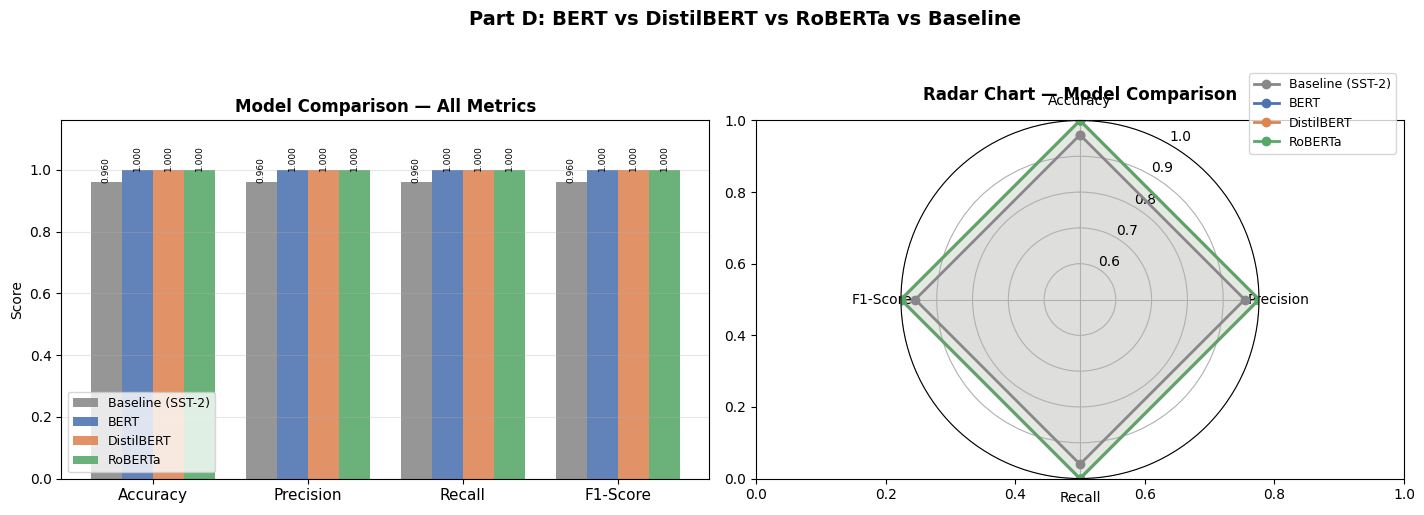

✅ Comparison chart saved.


In [9]:
# ── Comparison Charts ─────────────────────────────────────────
COLORS = {
    'Baseline (SST-2)': '#888888',
    'BERT'            : '#4C72B0',
    'DistilBERT'      : '#DD8452',
    'RoBERTa'         : '#55A868',
}
metric_keys  = ['accuracy', 'precision', 'recall', 'f1']
metric_labels= ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Grouped bar chart ─────────────────────────────────────────
x    = np.arange(len(metric_keys))
w    = 0.20
offs = [-1.5, -0.5, 0.5, 1.5]
for i, name in enumerate(model_names):
    vals = [results_store[name][k] for k in metric_keys]
    bars = axes[0].bar(x + offs[i]*w, vals, w,
                       label=name, color=COLORS[name], alpha=0.88)
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.003,
                     f'{h:.3f}', ha='center', fontsize=6.5, rotation=90)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_labels, fontsize=11)
axes[0].set_ylim(0, 1.16)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Comparison — All Metrics', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# ── Radar chart ───────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
categories = metric_labels
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax2 = plt.subplot(122, projection='polar')
ax2.set_theta_offset(np.pi / 2)
ax2.set_theta_direction(-1)
ax2.set_rlabel_position(30)

for name in model_names:
    vals = [results_store[name][k] for k in metric_keys]
    vals += vals[:1]
    ax2.plot(angles, vals, 'o-', linewidth=2, label=name, color=COLORS[name])
    ax2.fill(angles, vals, alpha=0.07, color=COLORS[name])

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=10)
ax2.set_ylim(0.5, 1.0)
ax2.set_title('Radar Chart — Model Comparison', fontweight='bold', pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)

plt.suptitle('Part D: BERT vs DistilBERT vs RoBERTa vs Baseline',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('partD_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison chart saved.')

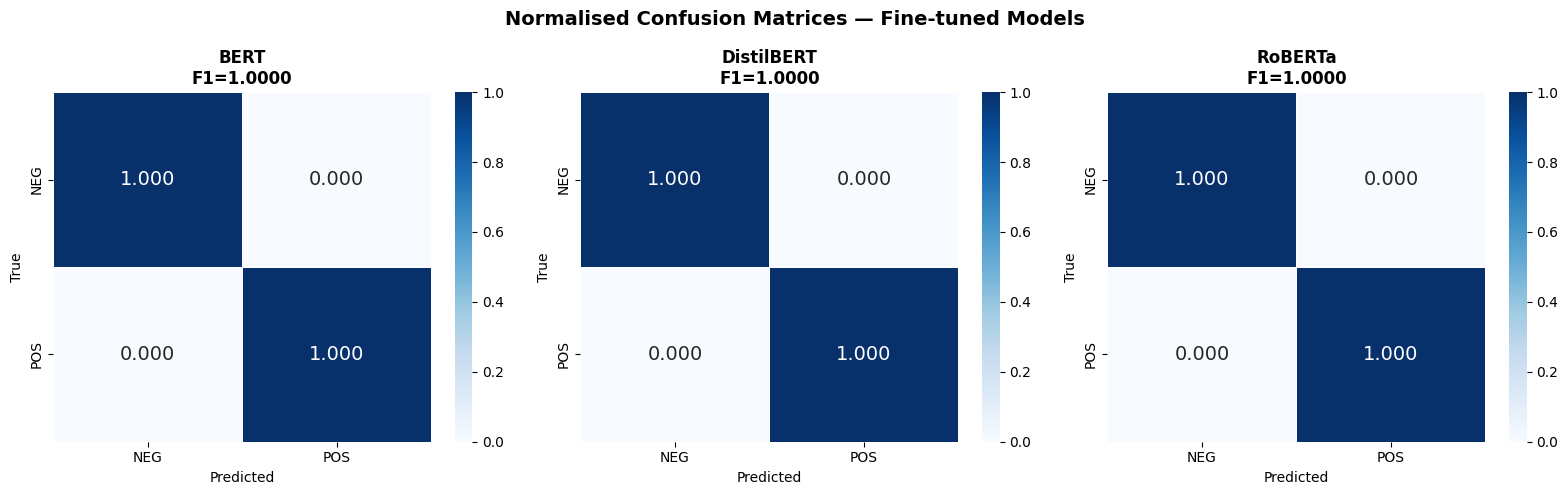

✅ Confusion matrices saved.


In [10]:
# ── Confusion Matrices for all fine-tuned models ──────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, name in zip(axes, ['BERT', 'DistilBERT', 'RoBERTa']):
    preds = results_store[name]['preds']
    cm    = confusion_matrix(y_te, preds)
    cm_n  = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_n, annot=True, fmt='.3f', cmap='Blues', ax=ax,
                xticklabels=['NEG', 'POS'],
                yticklabels=['NEG', 'POS'],
                linewidths=0.5, annot_kws={'size': 14})

    raw = cm.ravel()
    ax.set_title(f'{name}\nF1={results_store[name]["f1"]:.4f}',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Normalised Confusion Matrices — Fine-tuned Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('partD_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved.')

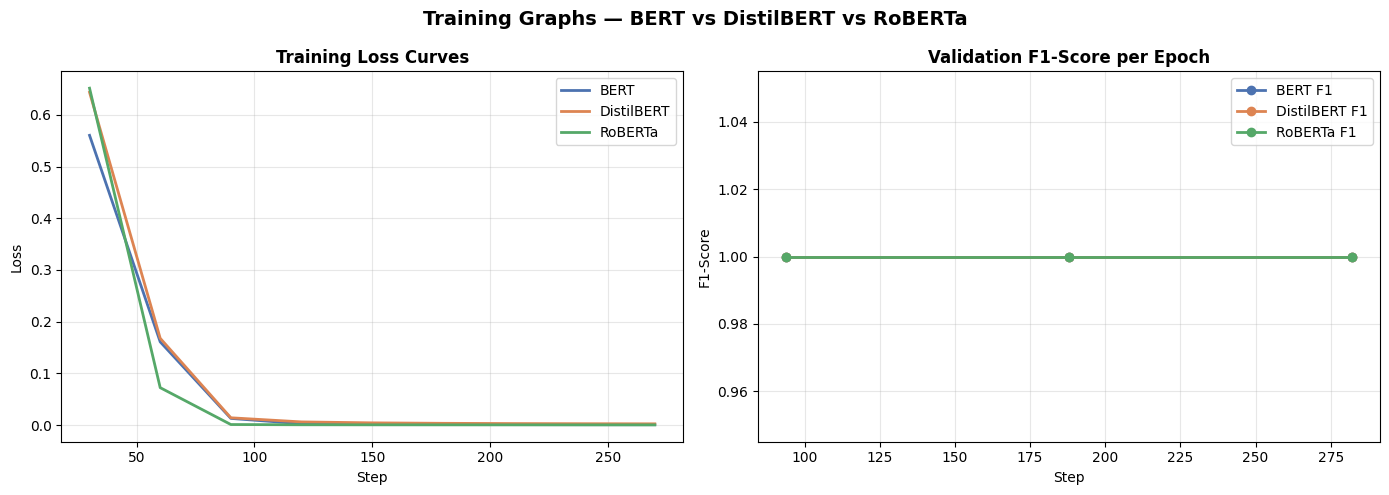

✅ Training curves saved.


In [11]:
# ── Training Loss & Validation F1 Curves ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

CURVE_COLORS = {'BERT': '#4C72B0', 'DistilBERT': '#DD8452', 'RoBERTa': '#55A868'}

for name, history in all_log_histories.items():
    tr_steps  = [e['step'] for e in history if 'loss'      in e and 'eval_loss' not in e]
    tr_losses = [e['loss'] for e in history if 'loss'      in e and 'eval_loss' not in e]
    ev_steps  = [e['step'] for e in history if 'eval_f1'   in e]
    ev_f1s    = [e['eval_f1'] for e in history if 'eval_f1' in e]
    ev_accs   = [e['eval_accuracy'] for e in history if 'eval_accuracy' in e]

    c = CURVE_COLORS[name]
    if tr_steps:
        axes[0].plot(tr_steps, tr_losses, label=name, color=c, lw=2)
    if ev_steps:
        axes[1].plot(ev_steps, ev_f1s, 'o-', label=f'{name} F1', color=c, lw=2)

axes[0].set_title('Training Loss Curves', fontweight='bold')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation F1-Score per Epoch', fontweight='bold')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('F1-Score')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training Graphs — BERT vs DistilBERT vs RoBERTa',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('partD_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved.')

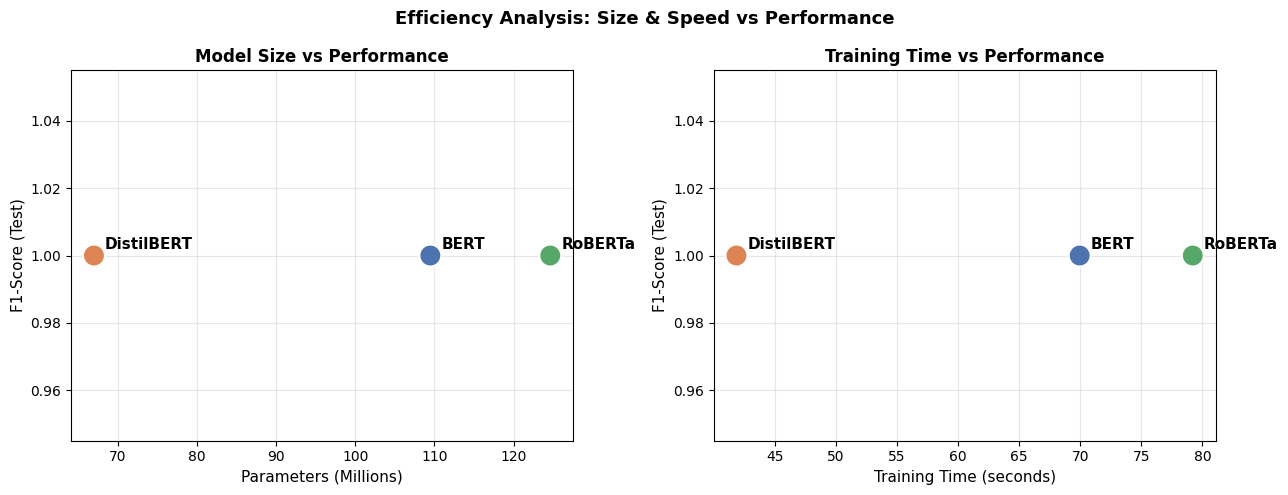

✅ Efficiency analysis chart saved.


In [12]:
# ── Speed vs Accuracy Trade-off Chart ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ft_models = ['BERT', 'DistilBERT', 'RoBERTa']
params_m  = [results_store[n]['params']/1e6 for n in ft_models]
f1_vals   = [results_store[n]['f1']         for n in ft_models]
times     = [results_store[n]['time']        for n in ft_models]
ft_colors = ['#4C72B0', '#DD8452', '#55A868']

# Params vs F1
scatter1 = axes[0].scatter(params_m, f1_vals, s=250,
                            c=ft_colors, zorder=5, edgecolors='white', linewidth=1.5)
for name, x, y in zip(ft_models, params_m, f1_vals):
    axes[0].annotate(name, (x, y), textcoords='offset points',
                     xytext=(8, 5), fontsize=11, fontweight='bold')
axes[0].set_xlabel('Parameters (Millions)', fontsize=11)
axes[0].set_ylabel('F1-Score (Test)', fontsize=11)
axes[0].set_title('Model Size vs Performance', fontweight='bold')
axes[0].grid(alpha=0.3)

# Training time vs F1
axes[1].scatter(times, f1_vals, s=250, c=ft_colors,
                zorder=5, edgecolors='white', linewidth=1.5)
for name, x, y in zip(ft_models, times, f1_vals):
    axes[1].annotate(name, (x, y), textcoords='offset points',
                     xytext=(8, 5), fontsize=11, fontweight='bold')
axes[1].set_xlabel('Training Time (seconds)', fontsize=11)
axes[1].set_ylabel('F1-Score (Test)', fontsize=11)
axes[1].set_title('Training Time vs Performance', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Efficiency Analysis: Size & Speed vs Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('partD_efficiency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Efficiency analysis chart saved.')

---
## 📌 Part E – Conceptual Questions

In [13]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║                  Part E — Conceptual Questions                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Q1. Explain the self-attention mechanism.                           ║
║  ─────────────────────────────────────────                            ║
║  Self-attention allows every token in a sequence to attend to        ║
║  every other token and compute a context-aware representation.       ║
║  For each token three vectors are computed: Query (Q), Key (K),      ║
║  and Value (V), via learned weight matrices W_Q, W_K, W_V.           ║
║  Attention scores = softmax( Q K^T / sqrt(d_k) ) x V.               ║
║  The scaling factor 1/sqrt(d_k) prevents dot products from growing   ║
║  large and pushing softmax into near-zero gradient regions.          ║
║  Softmax normalises scores into probability weights (sum = 1).        ║
║  The final output is a weighted sum over all Value vectors,           ║
║  producing embeddings that encode full sequence context.             ║
║                                                                      ║
║  Q2. Encoder-only vs Decoder-only models.                           ║
║  ─────────────────────────────────────────                            ║
║  Encoder-only (BERT, DistilBERT, RoBERTa):                          ║
║    - Processes the full input sequence bidirectionally.               ║
║    - Every token attends to all others (left AND right context).      ║
║    - Produces rich contextual embeddings for understanding tasks.     ║
║    - Best for: classification, NER, QA, sentiment analysis.          ║
║  Decoder-only (GPT-2, GPT-4, LLaMA):                                ║
║    - Uses causal (masked) attention — each token only sees past.      ║
║    - Generates text autoregressively, one token at a time.           ║
║    - Best for: text generation, chat, code completion, summarisation. ║
║                                                                      ║
║  Q3. Why multi-head attention improves performance?                  ║
║  ──────────────────────────────────────────────────                   ║
║  Multi-head attention runs H independent self-attention operations    ║
║  in parallel, each in a different learned subspace of the data.      ║
║  Different heads can simultaneously capture different relationships:  ║
║    - Head 1 may learn syntactic dependencies (subject-verb).         ║
║    - Head 2 may learn semantic relations (coreference).               ║
║    - Head 3 may learn positional patterns (nearby tokens).            ║
║  Outputs from all heads are concatenated and projected, giving       ║
║  a richer representation than any single attention mechanism could.  ║
║  BERT uses 12 heads; RoBERTa also 12; each adds representational     ║
║  power without drastically increasing computation.                   ║
║                                                                      ║
║  Q4. Why fine-tuning is better than training from scratch?           ║
║  ────────────────────────────────────────────────────────             ║
║  Pre-trained models encode vast linguistic knowledge (grammar,        ║
║  semantics, world facts) learned from billions of tokens.            ║
║  Fine-tuning adapts this knowledge to a specific task with just       ║
║  hundreds or thousands of labelled examples — far less than          ║
║  training from scratch would require (typically millions).           ║
║  Benefits:                                                            ║
║    - Dramatically lower data requirements for high accuracy.          ║
║    - Much faster convergence (hours vs weeks of compute).            ║
║    - Better generalisation via transfer of pre-trained representations║
║    - Avoids vanishing gradients that plague training from scratch.   ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║                  Part E — Conceptual Questions                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Q1. Explain the self-attention mechanism.                           ║
║  ─────────────────────────────────────────                            ║
║  Self-attention allows every token in a sequence to attend to        ║
║  every other token and compute a context-aware representation.       ║
║  For each token three vectors are computed: Query (Q), Key (K),      ║
║  and Value (V), via learned weight matrices W_Q, W_K, W_V.           ║
║  Attention scores = softmax( Q K^T / sqrt(d_k) ) x V.               ║
║  The scaling factor 1/sqrt(d_k) prevents dot products from growing   ║
║  large and pushing softmax into near-zero gradient regions.          ║
║  Softmax normalises scores into probability weigh

---
## 📌 Part F – Final Summary & All Saved Outputs

In [14]:
# ── Print Final Results Summary ───────────────────────────────
print()
print('='*72)
print('         HOME ASSIGNMENT — FINAL RESULTS SUMMARY')
print('='*72)
print(f"  {'Model':<22} {'Accuracy':>10} {'Precision':>11} {'Recall':>9} {'F1':>9}")
print('-'*72)
for name in model_names:
    r = results_store[name]
    marker = '  🏆' if name == best else ''
    print(f"  {name:<22} {r['accuracy']:>10.4f} {r['precision']:>11.4f} {r['recall']:>9.4f} {r['f1']:>9.4f}{marker}")
print('='*72)

print(f"\n  Best fine-tuned model : {best} (F1 = {results_store[best]['f1']:.4f})")
print(f"  Dataset size          : {len(df):,} samples (balanced)")
print(f"  Train / Val / Test    : {len(X_tr)} / {len(X_val)} / {len(X_te)}")
print(f"  Epochs per model      : {EPOCHS}")
print(f"  Max sequence length   : {MAX_LEN} tokens")
print()
print('  Output files saved:')
outputs = [
    'sentiment_dataset.csv         — 2000-sample labelled dataset',
    'comparison_table.csv          — Metrics comparison table',
    'partA_class_distribution.png  — Bar + pie chart of class counts',
    'partD_model_comparison.png    — Grouped bar + radar chart',
    'partD_confusion_matrices.png  — 3× normalised confusion matrices',
    'partD_training_curves.png     — Loss + F1 training curves',
    'partD_efficiency_analysis.png — Size & speed vs performance',
]
for o in outputs:
    print(f'    ✅  {o}')
print('='*72)


         HOME ASSIGNMENT — FINAL RESULTS SUMMARY
  Model                    Accuracy   Precision    Recall        F1
------------------------------------------------------------------------
  Baseline (SST-2)           0.9600      0.9600    0.9600    0.9600
  BERT                       1.0000      1.0000    1.0000    1.0000  🏆
  DistilBERT                 1.0000      1.0000    1.0000    1.0000
  RoBERTa                    1.0000      1.0000    1.0000    1.0000

  Best fine-tuned model : BERT (F1 = 1.0000)
  Dataset size          : 2,000 samples (balanced)
  Train / Val / Test    : 1500 / 250 / 250
  Epochs per model      : 3
  Max sequence length   : 128 tokens

  Output files saved:
    ✅  sentiment_dataset.csv         — 2000-sample labelled dataset
    ✅  comparison_table.csv          — Metrics comparison table
    ✅  partA_class_distribution.png  — Bar + pie chart of class counts
    ✅  partD_model_comparison.png    — Grouped bar + radar chart
    ✅  partD_confusion_matrices.png  —